# Basic CrocoDash Tutorial

Set up a basic regional ocean run!

A typical workflow of utilizing CrocoDash consists of four main steps:

1. Generate a regional MOM6 domain.
2. Create the CESM case.
3. Prepare forcing data.
4. Build and run the case.


The first step in running CrocoDash is installing it! Please go to https://crocodile-cesm.github.io/CrocoDash/latest/installation.html to install CrocoDash!

In [1]:
from CrocoDash.grid import Grid
from CrocoDash.topo import Topo
from CrocoDash.vgrid import VGrid
from CrocoDash.case import Case
import matplotlib.pyplot as plt
from pathlib import Path

# SECTION 1: Generate a regional MOM6 domain

We begin by defining a regional MOM6 domain using CrocoDash. To do so, we first generate a horizontal grid. We then generate the topography by remapping an existing bathymetric dataset to our horizontal grid. Finally, we define a vertical grid.

## Step 1.1: Horizontal Grid

📖 [Grid documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)

In [2]:
# CrocoDash uses an object-oriented style of programming. Grid() is an object here.
grid = Grid(resolution = 1/36, # in degrees
  xstart = 279, # min longitude in [0, 360]
  lenx = 20.0, # longitude extent in degrees
  ystart = 28.0, # min latitude in [-90, 90]
  leny = 10.0, # latitude extent in degrees
  name = "gulf_stream")

## Step 1.2: Topography


In [3]:
topo = Topo(grid = grid,
    min_depth = 100, # in meters
)

In [4]:
bathymetry_path= Path("/glade/campaign/cgd/oce/projects/CROCODILE/workshops/2026/CrocoDash/data/gebco_2026/GEBCO_2026_coarse_x8.nc")
# The GEBCO bathymetry path on Derecho is: /glade/campaign/cgd/oce/projects/CROCODILE/workshops/2026/CrocoDash/data/gebco_2026/GEBCO_2026.nc

if not bathymetry_path.exists():
    raise FileNotFoundError("Bathymetry file not found, please replace with path to bathymetry file")

# Move data onto the topography object
topo.set_from_dataset(
    bathymetry_path = bathymetry_path,
    longitude_coordinate_name="lon",
    latitude_coordinate_name="lat",
    vertical_coordinate_name="elevation",
    depth_method = "xesmf",
    mask_method = "dataset")

Slicing source bathymetry to domain: (279.0, 299.0) x (28.0, 38.0) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2026_coarse_x8.nc):
    dlon = 120.0 arcsec  (0.033333°)
    dlat = 120.0 arcsec  (0.033333°)
    dx   ~ 3287 m)
    dy   ~ 3706 m

  Model grid (T-cell spacing):
    median = 2.83 km
    min    = 2.74 km
    max    = 2.90 km

  Resolution ratio (model dx / dataset dx):
    median = 0.9x
    max    = 0.9x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: direct_xesmf_regrid()  (bilinear / conservative)
    Ratio 0.9x is below the threshold where Cressman
    likely provides benefit over xesmf regridding.
**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_depth_from_xesmf()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            `

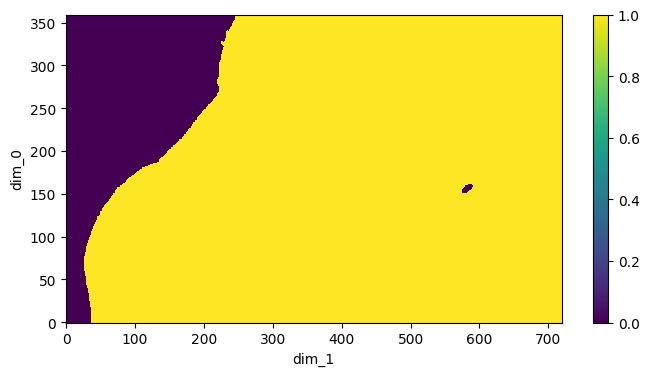

In [5]:
topo.basintmask.plot(size=4, aspect = grid.nx / grid.ny)

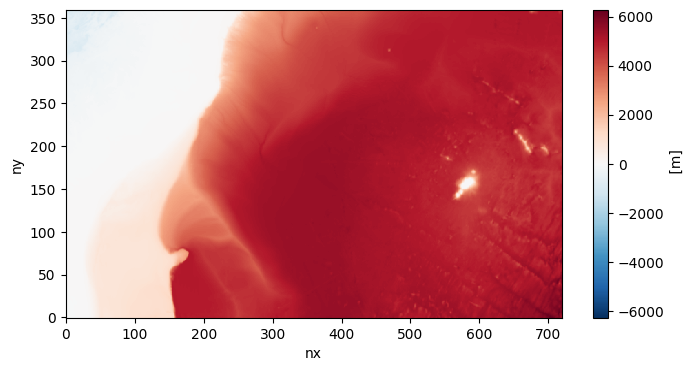

In [6]:
# Erases the smaller water bodies 
topo.keep_largest_basin()
topo.depth.plot(size=4, aspect = grid.nx / grid.ny)

In [7]:
## Optionally, uncomment the below lines to further modify the topography interactively
# %matplotlib ipympl
# from CrocoDash.topo_editor import TopoEditor
# TopoEditor(topo)

## Step 1.3: Vertical Grid

📖 [Grid documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/1_grids.html)

In [7]:
vgrid  = VGrid.hyperbolic(
    nk = 32, # number of vertical levels
    depth = topo.max_depth,
    ratio=50.0 # target ratio of top to bottom layer thicknesses
)

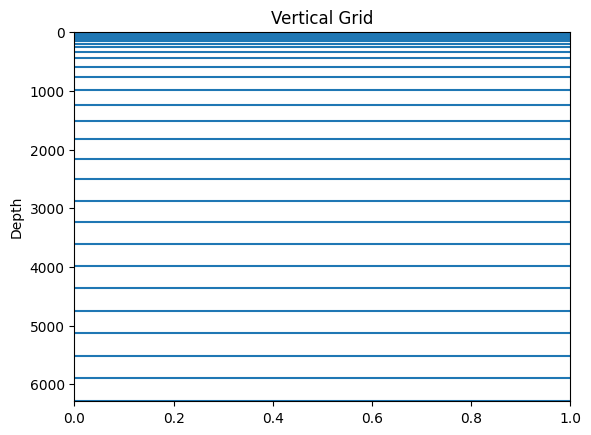

In [8]:
plt.close()
# Create the plot
for depth in vgrid.zi:
    plt.axhline(y=depth, linestyle='-')  # Horizontal lines

plt.ylim(max(vgrid.zi) + 10, min(vgrid.zi) - 10)  # Invert y-axis so deeper values go down
plt.ylabel("Depth")
plt.title("Vertical Grid")
plt.show()

# SECTION 2: Create the CESM case

After generating the MOM6 domain, the next step is to create a CESM case using CrocoDash. This process is straightforward and involves instantiating the CrocoDash Case object. The Case object requires the following inputs:

 - CESM Source Directory: A local path to a compatible CESM source copy. For the workshop, this is the `CESM/` folder of your CROCODILEworkspace install.
 - Case Name: A unique name for the CESM case. For the workshop, cases go in the `croc_cases/` folder of your CROCODILEworkspace install, in a folder named after the case.
 - Input Directory: The directory where all necessary input files will be written. You don't need to put anything in it: CrocoDash creates it and fills it with the grid, bathymetry and forcing files automatically. For the workshop, it's the `croc_input/` folder of your CROCODILEworkspace install.
 - MOM6 Domain Objects: The horizontal grid, topography, and vertical grid created in the previous section.
 - Project ID: (Optional) A project ID, if required by the machine. For the workshop, use `UCGD0009`.
 - Compset: The set of models to be used in the Case. Standalone Ocean, Ocean-BGC, Ocean-Seaice, Ocean-Wave, etc.

If you installed this notebook with CROCODILEworkspace, these paths and the project ID are already filled in for you in the code below.

## Step 2.1: Specify case name and directories:

Begin by specifying the case name and the necessary directory paths. Ensure the CESM root directory points to your own local copy of CESM. Below is an example setup:

In [9]:
# CESM case (experiment) name
casename = "gulf_stream.high_res.02"

# CESM source root (Update this path accordingly!!!)
cesmroot ="/glade/work/joneskellett/crocodile2026/CESM"

# Place where all your input files go 
inputdir = Path("/glade/work/joneskellett/crocodile2026/croc_input") / casename
    
# CESM case directory
caseroot = Path("/glade/work/joneskellett/crocodile2026/croc_cases") / casename

## Step 2.2: Create the Case

To create the CESM case, instantiate the `Case` object as shown below. This will automatically set up the CESM case based on the provided inputs: The `cesmroot` argument specifies the path to your local CESM source directory.
The `caseroot` argument defines the directory where the case will be created. CrocoDash will handle all necessary namelist modifications and XML changes to align with the MOM6 domain objects generated earlier.
The `job_queue` and `job_wallclock_time` arguments set the PBS queue and the walltime (`hh:mm:ss`) CESM requests when you submit the run; leave them out to use the machine defaults.

📖 [Case documentation](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/2_case_setup.html)

### Compset quick-reference

The `compset` argument controls which model components are active. Start with the ocean-only default and swap or add stubs as needed:

| What you want | Change in `compset=` |
|---|---|
| **Ocean only (default)** | **`compset="CR_JRA"`** |
| + Waves (WW3) | `compset="CWR_JRA"` |
| + Sea ice (CICE6) | change `CWR_JRA` → `GWR_JRA` |
| + Biogeochemistry (MARBL) | add `%MARBL-BIO` to the MOM6 component, e.g. `MOM6%REGIONAL%MARBL-BIO` |
| + Data runoff (GLOFAS) | use `CWR_JRA_GLOFAS` |
| + Data runoff (JRA) | use `CWR_JRA` with `DROF%JRA` (see runoff notebook) |

For a deeper dive into each option:
- **CICE or BGC**: [Case Setup, Sections 3–4](case_setup.ipynb#case-cice)
- **Runoff (GLOFAS / JRA / custom)**: [Configure Forcings, Section 5](configure_forcings.ipynb#forcings-runoff)


Compset filestrings for BGC: https://crocodile-cesm.github.io/CrocoDash/latest/for_users/datasets.html

In [10]:
# Case is the "control desk" where you put the input
case = Case(
    cesmroot = cesmroot,
    caseroot = caseroot,
    inputdir = inputdir,
    ocn_grid = grid,
    ocn_vgrid = vgrid,
    ocn_topo = topo,
    project = 'UCGD0009', # Enter Project ID for PBS Queue
#    job_queue = "tutorial", # PBS queue the run is submitted to
    job_wallclock_time = "02:00:00", # hh:mm:ss walltime requested for the run
    override = True,
    machine = "derecho",
    compset = "CR_JRA")

WARNING [CIME.XML.grids] Schema validity test fails for /glade/work/joneskellett/crocodile2026/CESM/ccs_config/config_grids_nuopc.xml


Creating case...

Running the create_newcase tool with the following command:

/glade/work/joneskellett/crocodile2026/CESM/cime/scripts/create_newcase --compset CR_JRA --res USER_RES --case /glade/work/joneskellett/crocodile2026/croc_cases/gulf_stream.high_res.02 --machine derecho --run-unsupported --handle-preexisting-dirs a --pecount L --project UCGD0009 --non-local 

The create_newcase command was successful.

• Updating case xml variables to include newly generated ocean grid "gulf_stream" with the following properties:
 nx: 720, ny: 360. ocean mesh: /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/ocn/ESMF_mesh_gulf_stream_e65ed3.nc.

./xmlchange OCN_GRID=gulf_stream --non-local
./xmlchange OCN_NX=720 --non-local
./xmlchange OCN_NY=360 --non-local
./xmlchange OCN_DOMAIN_MESH=/glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/ocn/ESMF_mesh_gulf_stream_e65ed3.nc --non-local
./xmlchange ICE_GRID=gulf_stream --non-local
./xmlchange ICE_N

# Section 3: Prepare ocean forcing data

We need to cut out our ocean forcing. The package expects an initial condition and one time-dependent segment per non-land boundary. Naming convention is `"east_unprocessed"` for segments and `"ic_unprocessed"` for the initial condition.

In this notebook, we are forcing with the Copernicus Marine "Glorys" reanalysis dataset. There's a function in the `CrocoDash` package, called `configure_forcings`, that generates a bash script to download the correct boundary forcing files for your experiment. First, you will need to create an account with Copernicus, and then call `copernicusmarine login` to set up your login details on your machine. Then you can run the `get_glorys_data.sh` bash script.

## Step 3.1 Configure Initial Conditions and Forcings

📖 [Configure forcings docs](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/3a_configure_forcings.html) · [Available datasets](https://crocodile-cesm.github.io/CrocoDash/latest/for_users/datasets.html)

We can edit the forcing files at this point:



NOTE: CrocoDash only has BGC for before 2006!

In [11]:
date_range = ["2002-11-01 00:00:00", "2003-01-01 00:00:00"]

In [12]:
case.configure_forcings(
    date_range = date_range,
    boundaries=["north","east","south"],
    product_name="cesm_pop_output",
    function_name="get_cesm_single_variable_data",
    marbl_ic_filepath = "/glade/campaign/collections/gdex/data/d651077/cesmdata/inputdata/ocn/mom/tx0.66v1/ecosys_jan_IC_omip_latlon_1x1_180W_c231221.nc")

INFO [CrocoDash.forcing.base] [REQUIRED] Activating StreamYears
INFO [CrocoDash.forcing.base] [SKIP] BGC incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCIC incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCIronForcing incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCRiverNutrients incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] Chl missing args: ['chl_processed_filepath']
INFO [CrocoDash.forcing.base] [SKIP] CICE incompatible with compset
INFO [CrocoDash.forcing.base] [REQUIRED] Activating conditions
INFO [CrocoDash.forcing.base] [SKIP] Runoff incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] tides missing args: ['tpxo_elevation_filepath', 'tpxo_velocity_filepath', 'tidal_constituents']
INFO [CrocoDash.forcing.base] [SKIP] WW3 incompatible with compset
INFO [CrocoDash.forcing.base] Configuring StreamYears


WARNING [CrocoDash.forcing.atm] DROF stream years left at CESM defaults: no active drof


Adding parameter changes to user_nl_datm_streams:

  ! Align CORE_IAF_JRA_1p5_2023 streams with the run dates (CrocoDash: CDEPS defaults to year_align=1)
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_first = 2000
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_last = 2004
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_align = 2000
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:datafiles = /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2000.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2001.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2002.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2003.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2004.210504.nc
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_first = 2000
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_last = 2004
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_align = 2000
 

#### !!! STOP !!! 

Check /work/crocodile2026/croc_input/[CASE NAME]/external_forcings/config.json

- Make these numbers big if running for less than a year:
        "get_step_days": 2000,
        "regrid_step_days": 2000,

```{admonition} Optional forcing additions
:class: tip

You can extend `configure_forcings` with any of these before calling `process_forcings`:

- **Tides**: [Configure Forcings, Section 3](configure_forcings.ipynb#forcings-tides)
- **Chlorophyll**: [Configure Forcings, Section 4](configure_forcings.ipynb#forcings-chlorophyll)
- **Alternative data products** (not GLORYS), [Configure Forcings, Section 2](configure_forcings.ipynb#forcings-data-products)
- **Long runs / offline OBC**: [Process Forcings, Section 2](process_forcings.ipynb#process-offline)
```

##  Step 3.3: Process forcing data

In this final step, we call the `process_forcings` method of CrocoDash to cut out and interpolate the initial condition as well as all boundaries. CrocoDash also updates MOM6 runtime parameters and CESM xml variables accordingly.

In [13]:
case.process_forcings()

INFO [CrocoDash.forcing.obc] Using tmask-derived bounding boxes for OBC data download.
INFO [CrocoDash.forcing.obc] GET [north]: 2002-11-01 → 2003-01-01
Parsing dataset...
2 file(s) found for variable 'UVEL'
2 file(s) found for variable 'VVEL'
2 file(s) found for variable 'SSH'
2 file(s) found for variable 'TEMP'
2 file(s) found for variable 'SALT'
Subsetted dataset for variable 'UVEL' saved to /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/extract_forcings/raw_data/UVEL_subset_36.5_39.5_284.40277777777777_300.4861111111111_20021101_20030101.nc
Subsetted dataset for variable 'VVEL' saved to /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/extract_forcings/raw_data/VVEL_subset_36.5_39.5_284.40277777777777_300.4861111111111_20021101_20030101.nc
Subsetted dataset for variable 'SSH' saved to /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/extract_forcings/raw_data/SSH_subset_36.5_39.5_284.40277777777777_300.48611

WARNING [regional_mom6.utils] Converted z_t from centimeters to m
WARNING [regional_mom6.utils] Converted z_t_150m from centimeters to m


No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping


WARNING [regional_mom6.utils] Converted u from centimeter/s to m/s
WARNING [regional_mom6.utils] Converted v from centimeter/s to m/s
WARNING [regional_mom6.utils] Converted eta from centimeter to m
WARNING [regional_mom6.validate] temp_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] salt_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] u_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] v_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] eta_segment_001 does not have a coordinates attribute


INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [north]: Regridding done for /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/extract_forcings/regridded_data/forcing_obc_segment_001_2002-11-01_2003-01-01.nc
INFO [CrocoDash.forcing.obc] REGRID [east]: 2000-day slices
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [east]: Spun up new proc
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [east]: Chunk start - end date: [2002-11-01] - [2003-01-01]
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [east]: Selecting raw files
INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [east]: Performing regrid


...

No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping


WARNING [regional_mom6.validate] temp_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] salt_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] u_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] v_segment_003 does not have a coordinates attribute
WARNING [regional_mom6.validate] eta_segment_003 does not have a coordinates attribute


INFO [CrocoDash.forcing.obc] PROC [0] - REGRID [south]: Regridding done for /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/extract_forcings/regridded_data/forcing_obc_segment_003_2002-11-01_2003-01-01.nc
INFO [CrocoDash.forcing.obc] MERGE [north]
INFO [CrocoDash.forcing.obc] Saved merged boundary at /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/ocn/forcing_obc_segment_001.nc
INFO [CrocoDash.forcing.obc] MERGE [east]
INFO [CrocoDash.forcing.obc] Saved merged boundary at /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/ocn/forcing_obc_segment_002.nc
INFO [CrocoDash.forcing.obc] MERGE [south]
INFO [CrocoDash.forcing.obc] Saved merged boundary at /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/ocn/forcing_obc_segment_003.nc
INFO [CrocoDash.forcing.obc] OBC processing complete.
INFO [CrocoDash.forcing.ic] [CESM_POP_OUTPUT.get_cesm_single_variable_data] Usage: Requires access to the `dat

WARNING [regional_mom6.validate] eta_t does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable eta_t does not have 4 dimensions
WARNING [regional_mom6.validate] temp does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable temp does not have 4 dimensions
WARNING [regional_mom6.validate] salt does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable salt does not have 4 dimensions
WARNING [regional_mom6.validate] u does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable u does not have 4 dimensions
WARNING [regional_mom6.validate] v does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable v does not have 4 dimensions


INFO [CrocoDash.forcing.mom6] Start mom6_forge fill...
INFO [CrocoDash.forcing.mom6] ...end mom6_forge fill.
INFO [CrocoDash.forcing.ic] Successfully retrieved CESM_POP_OUTPUT initial condition data located in /glade/work/joneskellett/crocodile2026/croc_input/gulf_stream.high_res.02/ocn directory.
[timing] bc: 535.5s  ic: 126.8s  total: 662.3s
Case is ready to be built: /glade/work/joneskellett/crocodile2026/croc_cases/gulf_stream.high_res.02


In [14]:
print("You can now build and run your case at",caseroot)

You can now build and run your case at /glade/work/joneskellett/crocodile2026/croc_cases/gulf_stream.high_res.02


# Section 4: Build and run the case

After completing the previous steps, you are ready to build and run your CESM case. Begin by navigating to the case root directory specified during the case creation. Before proceeding, review the `user_nl_mom` file located in the case directory. This file contains MOM6 parameter settings that were automatically generated by CrocoDash. Carefully examine these parameters and make any necessary adjustments to fine-tune the model for your specific requirements. While CrocoDash aims to provide a solid starting point, further tuning and adjustments are typically necessary to improve the model for your use case.

Once you have reviewed and modified the parameters as needed, you can build and execute the case using the following commands. CESM cases must be built and submitted on the machine you passed as `machine` when creating the `Case`. For the workshop, that's **Derecho** (not Casper), so the commands start by logging in to Derecho and going to the case directory:
```
ssh derecho
cd /glade/work/joneskellett/crocodile2026/croc_cases/bering_ocn.001
./xmlchange JOB_QUEUE=tutorial --force
qcmd -A UCGD0009 -- ./case.build
./case.submit
```

# Read Model Output

In [3]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from datetime import datetime, timedelta
import cftime
import matplotlib.animation as animation
from IPython.display import HTML, display

In [4]:
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure titl

#### Output Directories

In [5]:
lr_out_dir = '/glade/u/home/joneskellett/scratch/archive/gulf_stream.003/ocn/hist/' # low-resolution (1/12)
lr_no_wind_out_dir = '/glade/u/home/serenan/scratch/archive/nwa_ocn_noWind.001/ocn/hist/' # low-resolution (1/12) no wind stress
hr_out_dir = '/glade/u/home/joneskellett/scratch/archive/gulf_stream.high_res.02/ocn/hist/' # high-resolution (1/36)

#### Daily MOM Output

In [6]:
lr_sfc_ds = xr.open_mfdataset([lr_out_dir + 'gulf_stream.003.mom6.h.sfc.2002-%s.nc'%(month) for month in ['11','12']], decode_times=False)
lr_no_wind_sfc_ds = xr.open_mfdataset([lr_no_wind_out_dir + 'nwa_ocn_noWind.001.mom6.h.sfc.2002-%s.nc'%(month) for month in ['11','12']], decode_times=False)
hr_sfc_ds = xr.open_mfdataset([hr_out_dir + 'gulf_stream.high_res.02.mom6.h.sfc.2002-%s.nc'%(month) for month in ['11','12']], decode_times=False)

In [7]:
lr_sfc_ds

<xarray.Dataset> Size: 394MB
Dimensions:       (time: 61, yh: 120, xh: 240, xq: 241, yq: 121, zi: 33, nbnd: 2)
Coordinates:
  * time          (time) float64 488B 7.307e+05 7.307e+05 ... 7.307e+05
  * yh            (yh) float64 960B 28.04 28.12 28.21 ... 37.79 37.88 37.96
  * xh            (xh) float64 2kB 279.0 279.1 279.2 279.3 ... 298.8 298.9 299.0
  * xq            (xq) float64 2kB 279.0 279.1 279.2 279.2 ... 298.8 298.9 299.0
  * yq            (yq) float64 968B 28.0 28.08 28.17 28.25 ... 37.83 37.92 38.0
  * zi            (zi) float64 264B 0.0 8.38 17.11 ... 5.883e+03 6.266e+03
  * nbnd          (nbnd) float64 16B 1.0 2.0
Data variables: (12/28)
    tos           (time, yh, xh) float32 7MB dask.array<chunksize=(30, 120, 240), meta=np.ndarray>
    tos_min       (time, yh, xh) float32 7MB dask.array<chunksize=(30, 120, 240), meta=np.ndarray>
    tos_max       (time, yh, xh) float32 7MB dask.array<chunksize=(30, 120, 240), meta=np.ndarray>
    sos           (time, yh, xh) float32 7MB dask.array<chunksize=(30, 120, 240), meta=np.ndarray>
    sos_min       (time, yh, xh) float32 7MB dask.array<chunksize=(30, 120, 240), meta=np.ndarray>
    sos_max       (time, yh, xh) float32 7MB dask.array<chunksize=(30, 120, 240), meta=np.ndarray>
    ...            ...
    T_adx_2d      (time, yh, xq) float32 7MB dask.array<chunksize=(30, 120, 241), meta=np.ndarray>
    T_ady_2d      (time, yq, xh) float32 7MB dask.array<chunksize=(30, 121, 240), meta=np.ndarray>
    average_T1    (time) float64 488B dask.array<chunksize=(30,), meta=np.ndarray>
    average_T2    (time) float64 488B dask.array<chunksize=(30,), meta=np.ndarray>
    average_DT    (time) float64 488B dask.array<chunksize=(30,), meta=np.ndarray>
    time_bounds   (time, nbnd) float64 976B dask.array<chunksize=(30, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: gulf_strea...
    associated_files:  areacello: gulf_stream.003.mom6.h.static.nc
    grid_type:         regular
    grid_tile:         N/A

#### Monthly MOM Output

In [8]:
lr_native_ds = xr.open_mfdataset([lr_out_dir + 'gulf_stream.003.mom6.h.native.2002-%s.nc'%(month) for month in ['11','12']], decode_times=False)
lr_no_wind_native_ds = xr.open_mfdataset([lr_no_wind_out_dir + 'nwa_ocn_noWind.001.mom6.h.native.2002-%s.nc'%(month) for month in ['11','12']], decode_times=False)
hr_native_ds = xr.open_mfdataset([hr_out_dir + 'gulf_stream.high_res.02.mom6.h.native.2002-%s.nc'%(month) for month in ['11','12']], decode_times=False)

### Grid Data 

In [9]:
lr_static_ds = xr.open_dataset(lr_out_dir + 'gulf_stream.003.mom6.h.static.nc', decode_times=False) # low-res same for wind/no wind
hr_static_ds = xr.open_dataset(hr_out_dir + 'gulf_stream.high_res.02.mom6.h.static.nc', decode_times=False)

### Crop Boundaries

NOT WORKING - TOO MUCH MEMORY

In [7]:
def make_mask(grid_ds):
    return ((grid_ds.geolat > 29) & (grid_ds.geolat < 37) & (grid_ds.geolon < 296)).compute()

In [8]:
lr_mask = make_mask(lr_static_ds)
hr_mask = make_mask(hr_static_ds)

In [9]:
lr_sfc_ds_cropped = lr_sfc_ds.where(lr_mask, drop=True)
lr_native_ds_cropped = lr_native_ds.where(lr_mask, drop=True)

lr_no_wind_sfc_ds_cropped = lr_no_wind_sfc_ds.where(lr_mask, drop=True)
lr_no_wind_native_ds_cropped = lr_no_wind_native_ds.where(lr_mask, drop=True)

hr_sfc_ds_cropped = hr_sfc_ds.where(hr_mask, drop=True)
hr_native_ds_cropped = hr_native_ds.where(hr_mask, drop=True)

In [10]:
del lr_sfc_ds, lr_no_wind_sfc_ds
del lr_native_ds, lr_no_wind_native_ds
del hr_sfc_ds, hr_native_ds

In [ ]:
lr_static_ds_cropped = lr_static_ds.where(lr_mask, drop=True)
hr_static_ds_cropped = hr_static_ds.where(hr_mask, drop=True)

### PLOT 

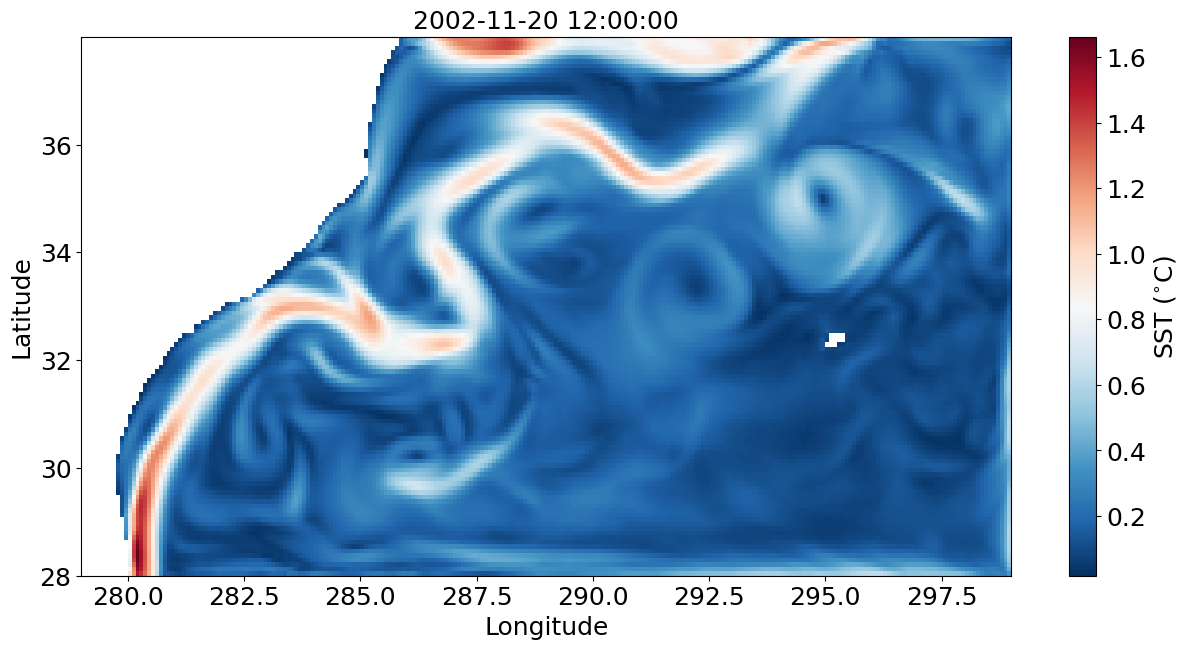

In [17]:
ds = lr_sfc_ds

index=19
fig,ax = plt.subplots(1,1,figsize=(15,7))
plot = ax.pcolormesh(lr_static_ds.geolon,lr_static_ds.geolat,ds.speed[index],cmap='plasma')

plt.colorbar(plot,label='Speed (m/s)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# NOTE: Need to convert the time ignoring leap years
ax.set_title(cftime.num2date(ds.time[index].values, units="days since 0001-01-01 00:00:00", calendar="noleap"))
plt.show()

### MOVIE 

In [15]:
date_range = ["2002-11-01 00:00:00", "2003-01-01 00:00:00"]

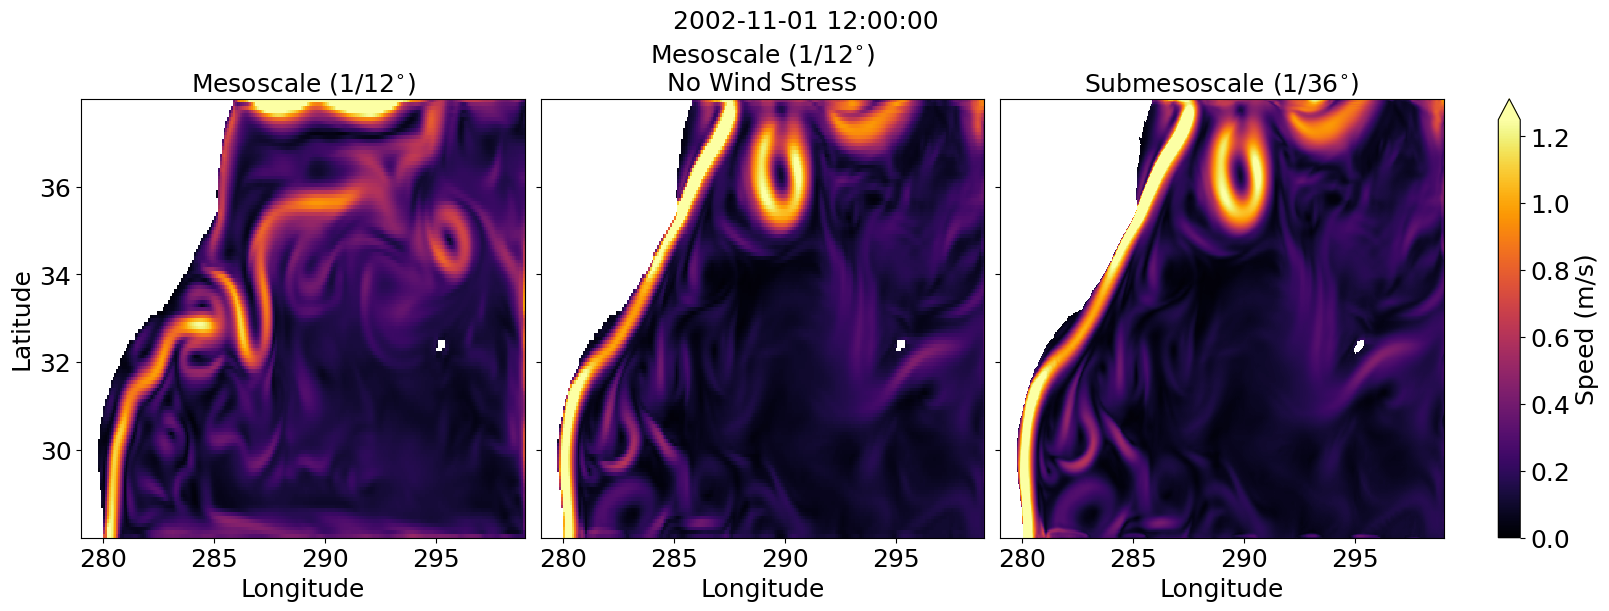

In [16]:
var = 'speed'
vmin, vmax = 0, 1.25
cmap = 'inferno'

# Set up the initial frame
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True, constrained_layout=True)

initial_index = 0

data_vars = [lr_sfc_ds[var], lr_no_wind_sfc_ds[var], hr_sfc_ds[var]]
grids = [lr_static_ds,lr_static_ds,hr_static_ds]
titles = ['Mesoscale (1/12$^{\circ}$)', 'Mesoscale (1/12$^{\circ}$)\nNo Wind Stress', 'Submesoscale (1/36$^{\circ}$)']

# Create the three initial plots
plots = []
for ax, data, grid, title in zip(axes, data_vars, grids, titles):

    plot = ax.pcolormesh(grid.geolon,grid.geolat, data[initial_index],cmap=cmap, vmin=vmin, vmax=vmax)
    plots.append(plot)
    ax.set_xlabel('Longitude')
    ax.set_title(title)

axes[0].set_ylabel('Latitude')

# One shared colorbar
cbar = fig.colorbar(plots[0], ax=axes, label='Speed (m/s)', extend='max', fraction=0.025, pad=0.04)

def update(frame):
    global plots

    # Remove old plots
    for plot in plots:
        plot.remove()

    plots = []

    # Draw new frame
    for ax, data, grid in zip(axes, data_vars, grids):
        plot = ax.pcolormesh(grid.geolon, grid.geolat, data[frame], cmap=cmap, vmin=vmin, vmax=vmax)
        plots.append(plot)

    date_str = cftime.num2date(lr_sfc_ds.time[frame].values, units="days since 0001-01-01 00:00:00", calendar="noleap")
    fig.suptitle(str(date_str))

    return plots


ani = animation.FuncAnimation(fig, update, frames=range(len(lr_sfc_ds.time)), interval=200, blit=False)

# Save the gif
save_dir = '/glade/u/home/joneskellett/work/crocodile2026/figs_n_gifs/'
ani.save(
    save_dir + 'speed_three_panel_%s_to_%s.gif' %
    (date_range[0][0:10], date_range[1][0:10]),
    writer='pillow',
    fps=5)

# OR render and display inside Jupyter
#plt.close()
#display(HTML(ani.to_html5_video()))

## Kinetic Energy Comparison

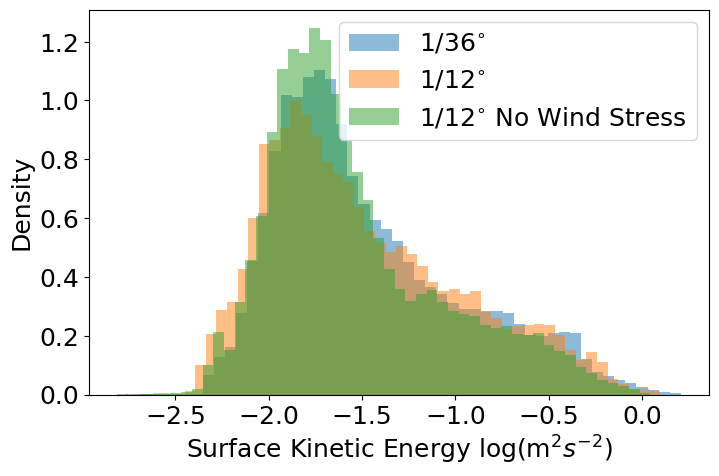

In [14]:
fig,ax = plt.subplots(1,1,figsize=(8,5))

ax.hist(np.log10(np.array(hr_native_ds.KE[:,0,:,:]).flatten()),
                bins=50,alpha=0.5,label='1/36$^{\circ}$',density=True)
ax.hist(np.log10(np.array(lr_native_ds.KE[:,0,:,:]).flatten()),
                bins=50,alpha=0.5,label='1/12$^{\circ}$',density=True)
ax.hist(np.log10(np.array(lr_no_wind_native_ds.KE[:,0,:,:]).flatten()),
                bins=50,alpha=0.5,label='1/12$^{\circ}$ No Wind Stress',density=True)

ax.set_xlabel('Surface Kinetic Energy log(m$^2 s^{-2}$)')
ax.set_ylabel('Density')
plt.legend()
plt.show()